
Building: triangle_opt1_integration_economy_computation.pdf


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_21660/2789505884.py:257: RuntimeWarning: divide by zero encountered in matmul
  xy = pts @ _TRI
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_21660/2789505884.py:257: RuntimeWarning: overflow encountered in matmul
  xy = pts @ _TRI
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_21660/2789505884.py:257: RuntimeWarning: invalid value encountered in matmul
  xy = pts @ _TRI


  Saved: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/03_trade_offs/triangle_opt1_integration_economy_computation.pdf


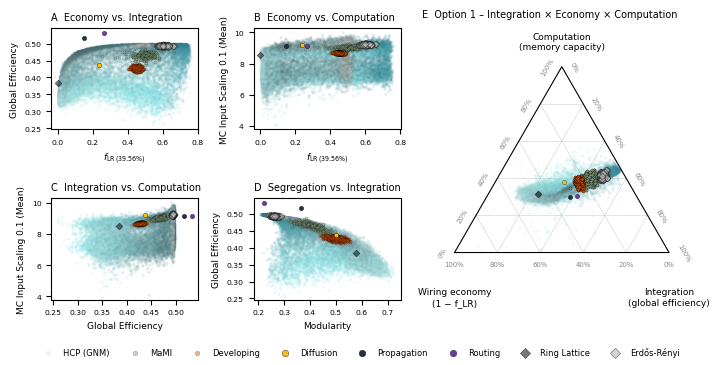


Building: triangle_opt2_routing_diffusion_economy.pdf


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_21660/2789505884.py:257: RuntimeWarning: divide by zero encountered in matmul
  xy = pts @ _TRI
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_21660/2789505884.py:257: RuntimeWarning: overflow encountered in matmul
  xy = pts @ _TRI
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_21660/2789505884.py:257: RuntimeWarning: invalid value encountered in matmul
  xy = pts @ _TRI


  Saved: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/03_trade_offs/triangle_opt2_routing_diffusion_economy.pdf


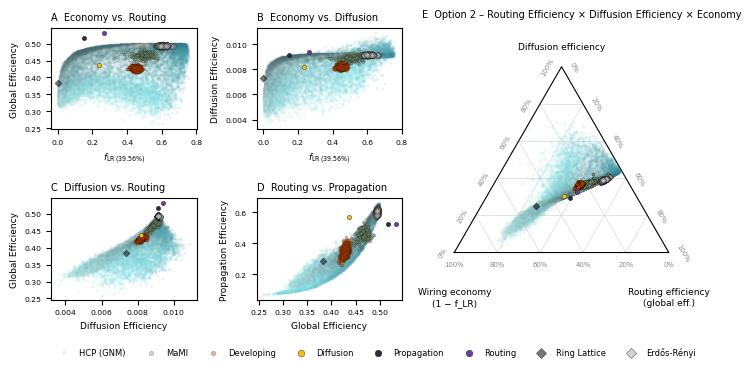


Building: triangle_opt3_composite_integration_economy_computation.pdf


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_21660/2789505884.py:257: RuntimeWarning: divide by zero encountered in matmul
  xy = pts @ _TRI
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_21660/2789505884.py:257: RuntimeWarning: overflow encountered in matmul
  xy = pts @ _TRI
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_21660/2789505884.py:257: RuntimeWarning: invalid value encountered in matmul
  xy = pts @ _TRI


  Saved: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/03_trade_offs/triangle_opt3_composite_integration_economy_computation.pdf


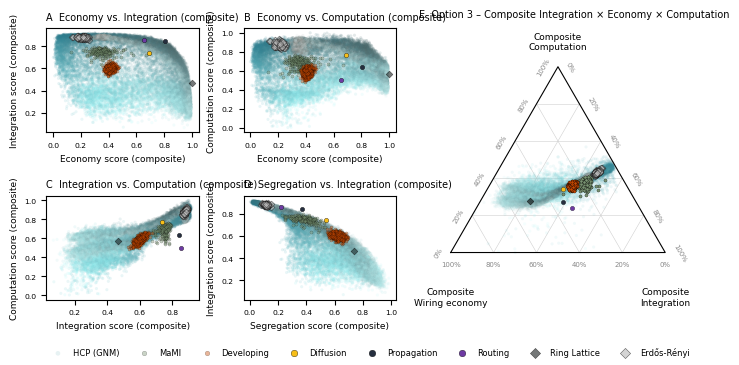


Done.


In [1]:
# %%
"""
Three triangle configurations for the Pareto morphospace figure.

Option 1 – Integration × Economy × Computation
    Classic conflict along the η axis: economy and integration strictly oppose
    each other; computation peaks near the edge-of-chaos in between.
    Directly mirrors the Fakhar 2025 finding.

Option 2 – Routing Efficiency × Diffusion Efficiency × Economy
    Replicates Avena-Koenigsberger et al. 2015 at 25k-network scale.
    Routing (shortest-path) and diffusion (random-walk) probe different
    aspects of connectivity; both conflict with wiring economy.

Option 3 – Composite Integration × Composite Economy × Composite Computation
    Uses the average of multiple normalized properties per optimization
    category, giving a more robust axis than any single property.
    Composite bounds are derived from the GNM dataset so all datasets
    are on the same absolute scale.
"""

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from vizman import viz

from config import COLOR_SCHEME, LABEL_MAP, PROPERTY_NAMES
from utils import get_combined_colors

# ── Data ─────────────────────────────────────────────────────────────────────

with open(
    "/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/all_datasets_precise_categories.pkl",
    "rb",
) as f:
    dict_with_all_datasets = pickle.load(f)

output_folder = Path(
    "/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/03_trade_offs"
)
output_folder.mkdir(parents=True, exist_ok=True)

INCLUDE_LEXIS = True

datasets_to_plot = [
    "hcp_schaefer_100_dataset_gnm",
    "suarez_MaMI_dataset",
    "lexis_data_developing",
    "kaysons_generated_networks_diffusion",
    "kaysons_generated_networks_propagation",
    "kaysons_generated_networks_routing",
    "ring_lattice_networks",
    "erdos_renyi_networks",
]

# all_datasets_precise_categories.pkl dropped several columns (mc_input_scaling,
# proportion_long_range_connections_0.3956, repertoire, eta, gamma) from the GNM entry.
# Replace it with the full GNM from all_datasets.pkl which has everything.
with open(
    "/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/all_datasets.pkl",
    "rb",
) as _f:
    _dict_full = pickle.load(_f)
dict_with_all_datasets["hcp_schaefer_100_dataset_gnm"] = _dict_full["hcp_schaefer_100_dataset_gnm"]

df_gnm = dict_with_all_datasets["hcp_schaefer_100_dataset_gnm"]
combined_colors = get_combined_colors(df_gnm)

# ── Composite score computation (Option 3) ────────────────────────────────────
# Each axis is the mean of several normalized properties. GNM min/max defines
# the reference range so all datasets land on the same absolute scale.

COMPOSITE_DEFS = {
    "composite_economy": {
        "props": ["proportion_long_range_connections_0.3956"],
        "invert": True,   # low f_LR = high economy
    },
    "composite_integration": {
        "props": ["global_efficiency", "diffusion_efficiency", "propagation_efficiency"],
        "invert": False,
    },
    "composite_computation": {
        "props": ["ipc_ipc_deg1_mean", "effective_dimensionality"],
        "invert": False,
    },
    "composite_segregation": {
        "props": ["modularity", "avg_clustering"],
        "invert": False,
    },
}

def _add_composite_columns(datasets, df_gnm_ref, composite_defs):
    """
    For each dataset and each composite definition, compute the mean of
    min-max normalized property scores and store as a new column.
    Normalization uses GNM bounds; out-of-range values are clipped to [0, 1].
    """
    for dataset, df in datasets.items():
        for col_name, defn in composite_defs.items():
            scores = []
            for prop in defn["props"]:
                if prop not in df.columns or prop not in df_gnm_ref.columns:
                    continue
                gnm_vals = df_gnm_ref[prop].dropna()
                rng = gnm_vals.max() - gnm_vals.min()
                if rng < 1e-12:
                    continue
                normalized = (df[prop] - gnm_vals.min()) / rng
                if defn["invert"]:
                    normalized = 1.0 - normalized
                scores.append(normalized.clip(0.0, 1.0))
            if scores:
                df[col_name] = pd.concat(scores, axis=1).mean(axis=1)

_add_composite_columns(dict_with_all_datasets, df_gnm, COMPOSITE_DEFS)

# ── Triangle configurations ───────────────────────────────────────────────────

# invert_economy: whether to compute 1 - value for the first (economy) axis.
# For composite scores the inversion is already baked in, so set to False.

CONFIGS = [
    {
        "filename":      "triangle_opt1_integration_economy_computation.pdf",
        "fig_title":     "Option 1 – Integration × Economy × Computation",
        "invert_economy": True,
        "ternary_cols":  {
            "left":   "proportion_long_range_connections_0.3956",
            "right":  "global_efficiency",
            "top":    "ipc_ipc_deg1_mean", # mc_input_scaling_0_1_mc_mean",
        },
        "ternary_labels": {
            "left":  "Wiring economy\n(1 − f_LR)",
            "right": "Integration\n(global efficiency)",
            "top":   "Computation\n(memory capacity)",
        },
        "scatter_panels": {
            "A": {
                "x": "proportion_long_range_connections_0.3956",
                "y": "global_efficiency",
                "title": "Economy vs. Integration",
            },
            "B": {
                "x": "proportion_long_range_connections_0.3956",
                "y": "mc_input_scaling_0_1_mc_mean",
                "title": "Economy vs. Computation",
            },
            "C": {
                "x": "global_efficiency",
                "y": "mc_input_scaling_0_1_mc_mean",
                "title": "Integration vs. Computation",
            },
            "D": {
                "x": "modularity",
                "y": "global_efficiency",
                "title": "Segregation vs. Integration",
            },
        },
    },
    {
        "filename":      "triangle_opt2_routing_diffusion_economy.pdf",
        "fig_title":     "Option 2 – Routing Efficiency × Diffusion Efficiency × Economy",
        "invert_economy": True,
        "ternary_cols":  {
            "left":   "proportion_long_range_connections_0.3956",
            "right":  "global_efficiency",
            "top":    "diffusion_efficiency",
        },
        "ternary_labels": {
            "left":  "Wiring economy\n(1 − f_LR)",
            "right": "Routing efficiency\n(global eff.)",
            "top":   "Diffusion efficiency",
        },
        "scatter_panels": {
            "A": {
                "x": "proportion_long_range_connections_0.3956",
                "y": "global_efficiency",
                "title": "Economy vs. Routing",
            },
            "B": {
                "x": "proportion_long_range_connections_0.3956",
                "y": "diffusion_efficiency",
                "title": "Economy vs. Diffusion",
            },
            "C": {
                "x": "diffusion_efficiency",
                "y": "global_efficiency",
                "title": "Diffusion vs. Routing",
            },
            "D": {
                "x": "global_efficiency",
                "y": "propagation_efficiency",
                "title": "Routing vs. Propagation",
            },
        },
    },
    {
        "filename":      "triangle_opt3_composite_integration_economy_computation.pdf",
        "fig_title":     "Option 3 – Composite Integration × Economy × Computation",
        "invert_economy": False,  # already inverted inside composite_economy
        "ternary_cols":  {
            "left":   "composite_economy",
            "right":  "composite_integration",
            "top":    "composite_computation",
        },
        "ternary_labels": {
            "left":  "Composite\nWiring economy",
            "right": "Composite\nIntegration",
            "top":   "Composite\nComputation",
        },
        "scatter_panels": {
            "A": {
                "x": "composite_economy",
                "y": "composite_integration",
                "title": "Economy vs. Integration (composite)",
            },
            "B": {
                "x": "composite_economy",
                "y": "composite_computation",
                "title": "Economy vs. Computation (composite)",
            },
            "C": {
                "x": "composite_integration",
                "y": "composite_computation",
                "title": "Integration vs. Computation (composite)",
            },
            "D": {
                "x": "composite_segregation",
                "y": "composite_integration",
                "title": "Segregation vs. Integration (composite)",
            },
        },
    },
]

# Add composite column names to PROPERTY_NAMES so axis labels are clean
PROPERTY_NAMES.update({
    "composite_economy":     "Economy score (composite)",
    "composite_integration": "Integration score (composite)",
    "composite_computation": "Computation score (composite)",
    "composite_segregation": "Segregation score (composite)",
})

# ── Shared ternary helpers ────────────────────────────────────────────────────

_TRI = np.array([
    [0.0, 0.0],              # vertex 0: left   (bottom-left)
    [1.0, 0.0],              # vertex 1: right  (bottom-right)
    [0.5, np.sqrt(3) / 2],  # vertex 2: top
])


def _bary_to_cart(a, b, c):
    pts = np.column_stack([a, b, c])
    xy = pts @ _TRI
    return xy[:, 0], xy[:, 1]


def _draw_ternary_frame(ax, labels):
    """Draw triangle boundary, gridlines, and vertex labels.

    labels: dict with keys "left", "right", "top".
    """
    tri_closed = np.vstack([_TRI, _TRI[0]])
    ax.plot(tri_closed[:, 0], tri_closed[:, 1], color="black", linewidth=0.8, zorder=5)

    for f in [0.2, 0.4, 0.6, 0.8]:
        for i, j, k in [(0, 1, 2), (1, 2, 0), (2, 0, 1)]:
            p0 = (1 - f) * _TRI[i] + f * _TRI[j]
            p1 = (1 - f) * _TRI[i] + f * _TRI[k]
            ax.plot([p0[0], p1[0]], [p0[1], p1[1]], color="#d0d0d0", linewidth=0.4, zorder=1)

    fontsize = 5
    offset = 0.04
    for f in [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]:
        px = (1 - f) * _TRI[0] + f * _TRI[1]
        ax.text(px[0], px[1] - offset, f"{1-f:.0%}",
                ha="center", va="top", fontsize=fontsize, color="#888888")
        pl = (1 - f) * _TRI[0] + f * _TRI[2]
        ax.text(pl[0] - offset * 0.8, pl[1], f"{f:.0%}",
                ha="right", va="center", fontsize=fontsize, color="#888888", rotation=60)
        pr = (1 - f) * _TRI[1] + f * _TRI[2]
        ax.text(pr[0] + offset * 0.8, pr[1], f"{1-f:.0%}",
                ha="left", va="center", fontsize=fontsize, color="#888888", rotation=-60)

    label_offset = 0.09
    ax.text(_TRI[0][0], _TRI[0][1] - label_offset * 1.8,
            labels["left"], ha="center", va="top", fontsize=6.5)
    ax.text(_TRI[1][0], _TRI[1][1] - label_offset * 1.8,
            labels["right"], ha="center", va="top", fontsize=6.5)
    ax.text(_TRI[2][0], _TRI[2][1] + label_offset * 0.8,
            labels["top"], ha="center", va="bottom", fontsize=6.5)

    ax.set_xlim(-0.15, 1.15)
    ax.set_ylim(-0.22, _TRI[2][1] + 0.18)
    ax.set_aspect("equal")
    ax.axis("off")


# ── Figure builder ────────────────────────────────────────────────────────────

def build_figure(cfg):
    fig, axes = plt.subplot_mosaic(
        """
        ABEE
        CDEE
        """,
        figsize=viz.cm_to_inch((18, 9)),
        layout="constrained",
    )

    # ── Scatter panels A–D ────────────────────────────────────────────────────

    for panel_id, pcfg in cfg["scatter_panels"].items():
        ax = axes[panel_id]

        for dataset in datasets_to_plot:
            if (not INCLUDE_LEXIS) and ("lexi" in dataset):
                continue

            df_merged = dict_with_all_datasets[dataset]
            x_col, y_col = pcfg["x"], pcfg["y"]
            if x_col not in df_merged.columns or y_col not in df_merged.columns:
                continue

            is_gnm = dataset == "hcp_schaefer_100_dataset_gnm"
            is_kaysons = "kaysons" in dataset
            is_reference = dataset in ("ring_lattice_networks", "erdos_renyi_networks")

            ax.scatter(
                df_merged[x_col],
                df_merged[y_col],
                color=combined_colors if is_gnm else COLOR_SCHEME[dataset],
                edgecolor="black" if not is_gnm else "none",
                linewidth=0.4 if is_reference else 0.25 if not is_gnm else 0,
                s=12 if is_reference else 10 if is_kaysons else 5,
                marker="D" if is_reference else "o",
                alpha=0.15 if is_gnm else 0.6 if is_reference else 1.0 if is_kaysons else 0.4,
                label=LABEL_MAP[dataset] if panel_id == "A" else None,
                zorder=5 if is_reference else 4 if is_kaysons else 1 if is_gnm else 2,
                rasterized=is_gnm,
            )

        ax.set_xlabel(PROPERTY_NAMES.get(x_col, x_col), fontsize=6.5)
        ax.set_ylabel(PROPERTY_NAMES.get(y_col, y_col), fontsize=6.5)
        ax.tick_params(labelsize=5.5)
        ax.set_title(f"{panel_id}  {pcfg['title']}", fontsize=7, loc="left")

    # ── Ternary panel E ───────────────────────────────────────────────────────

    ax_t = axes["E"]
    _draw_ternary_frame(ax_t, cfg["ternary_labels"])
    ax_t.set_title(f"E  {cfg['fig_title']}", fontsize=7, loc="left", pad=8)

    tc = cfg["ternary_cols"]
    cols = list(tc.values())

    # Global bounds from GNM (reference morphospace)
    gnm_cols = [c for c in cols if c in df_gnm.columns]
    if len(gnm_cols) < 3:
        print(f"  Warning: not all ternary columns found in GNM dataset for {cfg['filename']}")
        return fig

    _gnm_sub = df_gnm[cols].dropna()
    _global_min = np.array([
        1.0 - _gnm_sub[tc["left"]].max() if cfg["invert_economy"] else _gnm_sub[tc["left"]].min(),
        _gnm_sub[tc["right"]].min(),
        _gnm_sub[tc["top"]].min(),
    ])
    _global_max = np.array([
        1.0 - _gnm_sub[tc["left"]].min() if cfg["invert_economy"] else _gnm_sub[tc["left"]].max(),
        _gnm_sub[tc["right"]].max(),
        _gnm_sub[tc["top"]].max(),
    ])

    for dataset in datasets_to_plot:
        if (not INCLUDE_LEXIS) and ("lexi" in dataset):
            continue

        df_merged = dict_with_all_datasets[dataset]
        if not all(c in df_merged.columns for c in cols):
            continue

        raw = df_merged[cols].dropna()
        if len(raw) == 0:
            continue

        v_left  = (1.0 - raw[tc["left"]].values) if cfg["invert_economy"] else raw[tc["left"]].values
        v_right = raw[tc["right"]].values
        v_top   = raw[tc["top"]].values

        stack = np.column_stack([v_left, v_right, v_top])

        # Normalize using global GNM bounds
        for col_idx in range(3):
            rng = _global_max[col_idx] - _global_min[col_idx]
            if rng > 1e-12:
                stack[:, col_idx] = (stack[:, col_idx] - _global_min[col_idx]) / rng
            else:
                stack[:, col_idx] = 1.0 / 3.0
        stack = np.clip(stack, 0.0, 1.0)

        row_sums = stack.sum(axis=1, keepdims=True)
        row_sums[row_sums < 1e-12] = 1.0
        stack /= row_sums

        x_cart, y_cart = _bary_to_cart(stack[:, 0], stack[:, 1], stack[:, 2])

        is_gnm = dataset == "hcp_schaefer_100_dataset_gnm"
        is_kaysons = "kaysons" in dataset
        is_reference = dataset in ("ring_lattice_networks", "erdos_renyi_networks")
        ax_t.scatter(
            x_cart, y_cart,
            color=combined_colors if is_gnm else COLOR_SCHEME[dataset],
            edgecolor="black" if not is_gnm else "none",
            linewidth=0.4 if is_reference else 0.2 if not is_gnm else 0,
            s=12 if is_reference else 10 if is_kaysons else 5,
            marker="D" if is_reference else "o",
            alpha=0.1 if is_gnm else 0.7 if is_reference else 1.0,
            zorder=5 if is_reference else 4 if is_kaysons else 1 if is_gnm else 2,
            rasterized=is_gnm,
        )

    # ── Legend ────────────────────────────────────────────────────────────────

    handles, labels = axes["A"].get_legend_handles_labels()
    fig.legend(handles, labels, loc="outside lower center", ncol=len(labels),
               fontsize=6, markerscale=1.5, frameon=False)

    return fig


# ── Generate all three figures ────────────────────────────────────────────────

for cfg in CONFIGS:
    print(f"\nBuilding: {cfg['filename']}")
    fig = build_figure(cfg)
    out_path = output_folder / cfg["filename"]
    fig.savefig(out_path, bbox_inches="tight", dpi=200)
    print(f"  Saved: {out_path}")
    plt.show()

print("\nDone.")



Building: triangle_opt1_integration_economy_computation.pdf
  Saved: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/03_trade_offs/triangle_opt1_integration_economy_computation.pdf


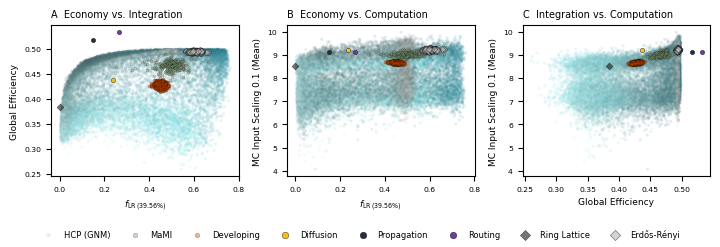


Done.


In [2]:

# ── Triangle configurations ───────────────────────────────────────────────────

# invert_economy: whether to compute 1 - value for the first (economy) axis.
# For composite scores the inversion is already baked in, so set to False.

CONFIGS = [
    {
        "filename":      "triangle_opt1_integration_economy_computation.pdf",
        "fig_title":     "Option 1 – Integration × Economy × Computation",
        "invert_economy": True,
        # "ternary_cols":  {
        #     "left":   "proportion_long_range_connections_0.3956",
        #     "right":  "global_efficiency",
        #     "top":    "ipc_ipc_deg1_mean", # mc_input_scaling_0_1_mc_mean",
        # },
        # "ternary_labels": {
        #     "left":  "Wiring economy\n(1 − f_LR)",
        #     "right": "Integration\n(global efficiency)",
        #     "top":   "Computation\n(memory capacity)",
        # },
        "scatter_panels": {
            "A": {
                "x": "proportion_long_range_connections_0.3956",
                "y": "global_efficiency",
                "title": "Economy vs. Integration",
            },
            "B": {
                "x": "proportion_long_range_connections_0.3956",
                "y": "mc_input_scaling_0_1_mc_mean",
                "title": "Economy vs. Computation",
            },
            "C": {
                "x": "global_efficiency",
                "y": "mc_input_scaling_0_1_mc_mean",
                "title": "Integration vs. Computation",
            },
            # "D": {
            #     "x": "modularity",
            #     "y": "global_efficiency",
            #     "title": "Segregation vs. Integration",
            # },
        },
    },
    # {
    #     "filename":      "triangle_opt2_routing_diffusion_economy.pdf",
    #     "fig_title":     "Option 2 – Routing Efficiency × Diffusion Efficiency × Economy",
    #     "invert_economy": True,
    #     "ternary_cols":  {
    #         "left":   "proportion_long_range_connections_0.3956",
    #         "right":  "global_efficiency",
    #         "top":    "diffusion_efficiency",
    #     },
    #     "ternary_labels": {
    #         "left":  "Wiring economy\n(1 − f_LR)",
    #         "right": "Routing efficiency\n(global eff.)",
    #         "top":   "Diffusion efficiency",
    #     },
    #     "scatter_panels": {
    #         "A": {
    #             "x": "proportion_long_range_connections_0.3956",
    #             "y": "global_efficiency",
    #             "title": "Economy vs. Routing",
    #         },
    #         "B": {
    #             "x": "proportion_long_range_connections_0.3956",
    #             "y": "diffusion_efficiency",
    #             "title": "Economy vs. Diffusion",
    #         },
    #         "C": {
    #             "x": "diffusion_efficiency",
    #             "y": "global_efficiency",
    #             "title": "Diffusion vs. Routing",
    #         },
    #         "D": {
    #             "x": "global_efficiency",
    #             "y": "propagation_efficiency",
    #             "title": "Routing vs. Propagation",
    #         },
    #     },
    # },
]

# ── Figure builder ────────────────────────────────────────────────────────────

def build_figure(cfg):
    fig, axes = plt.subplot_mosaic(
        """
        ABC
        """,
        figsize=viz.cm_to_inch((18, 6)),
        layout="constrained",
    )

    # ── Scatter panels A–D ────────────────────────────────────────────────────

    for panel_id, pcfg in cfg["scatter_panels"].items():
        ax = axes[panel_id]

        for dataset in datasets_to_plot:
            if (not INCLUDE_LEXIS) and ("lexi" in dataset):
                continue

            df_merged = dict_with_all_datasets[dataset]
            x_col, y_col = pcfg["x"], pcfg["y"]
            if x_col not in df_merged.columns or y_col not in df_merged.columns:
                continue

            is_gnm = dataset == "hcp_schaefer_100_dataset_gnm"
            is_kaysons = "kaysons" in dataset
            is_reference = dataset in ("ring_lattice_networks", "erdos_renyi_networks")

            ax.scatter(
                df_merged[x_col],
                df_merged[y_col],
                color=combined_colors if is_gnm else COLOR_SCHEME[dataset],
                edgecolor="black" if not is_gnm else "none",
                linewidth=0.4 if is_reference else 0.25 if not is_gnm else 0,
                s=12 if is_reference else 10 if is_kaysons else 5,
                marker="D" if is_reference else "o",
                alpha=0.15 if is_gnm else 0.6 if is_reference else 1.0 if is_kaysons else 0.4,
                label=LABEL_MAP[dataset] if panel_id == "A" else None,
                zorder=5 if is_reference else 4 if is_kaysons else 1 if is_gnm else 2,
                rasterized=is_gnm,
            )

        ax.set_xlabel(PROPERTY_NAMES.get(x_col, x_col), fontsize=6.5)
        ax.set_ylabel(PROPERTY_NAMES.get(y_col, y_col), fontsize=6.5)
        ax.tick_params(labelsize=5.5)
        ax.set_title(f"{panel_id}  {pcfg['title']}", fontsize=7, loc="left")

    # # ── Ternary panel E ───────────────────────────────────────────────────────

    # ax_t = axes["E"]
    # _draw_ternary_frame(ax_t, cfg["ternary_labels"])
    # ax_t.set_title(f"E  {cfg['fig_title']}", fontsize=7, loc="left", pad=8)

    # tc = cfg["ternary_cols"]
    # cols = list(tc.values())

    # # Global bounds from GNM (reference morphospace)
    # gnm_cols = [c for c in cols if c in df_gnm.columns]
    # if len(gnm_cols) < 3:
    #     print(f"  Warning: not all ternary columns found in GNM dataset for {cfg['filename']}")
    #     return fig

    # _gnm_sub = df_gnm[cols].dropna()
    # _global_min = np.array([
    #     1.0 - _gnm_sub[tc["left"]].max() if cfg["invert_economy"] else _gnm_sub[tc["left"]].min(),
    #     _gnm_sub[tc["right"]].min(),
    #     _gnm_sub[tc["top"]].min(),
    # ])
    # _global_max = np.array([
    #     1.0 - _gnm_sub[tc["left"]].min() if cfg["invert_economy"] else _gnm_sub[tc["left"]].max(),
    #     _gnm_sub[tc["right"]].max(),
    #     _gnm_sub[tc["top"]].max(),
    # ])

    # for dataset in datasets_to_plot:
    #     if (not INCLUDE_LEXIS) and ("lexi" in dataset):
    #         continue

    #     df_merged = dict_with_all_datasets[dataset]
    #     if not all(c in df_merged.columns for c in cols):
    #         continue

    #     raw = df_merged[cols].dropna()
    #     if len(raw) == 0:
    #         continue

    #     v_left  = (1.0 - raw[tc["left"]].values) if cfg["invert_economy"] else raw[tc["left"]].values
    #     v_right = raw[tc["right"]].values
    #     v_top   = raw[tc["top"]].values

    #     stack = np.column_stack([v_left, v_right, v_top])

    #     # Normalize using global GNM bounds
    #     for col_idx in range(3):
    #         rng = _global_max[col_idx] - _global_min[col_idx]
    #         if rng > 1e-12:
    #             stack[:, col_idx] = (stack[:, col_idx] - _global_min[col_idx]) / rng
    #         else:
    #             stack[:, col_idx] = 1.0 / 3.0
    #     stack = np.clip(stack, 0.0, 1.0)

    #     row_sums = stack.sum(axis=1, keepdims=True)
    #     row_sums[row_sums < 1e-12] = 1.0
    #     stack /= row_sums

    #     x_cart, y_cart = _bary_to_cart(stack[:, 0], stack[:, 1], stack[:, 2])

    #     is_gnm = dataset == "hcp_schaefer_100_dataset_gnm"
    #     is_kaysons = "kaysons" in dataset
    #     is_reference = dataset in ("ring_lattice_networks", "erdos_renyi_networks")
    #     ax_t.scatter(
    #         x_cart, y_cart,
    #         color=combined_colors if is_gnm else COLOR_SCHEME[dataset],
    #         edgecolor="black" if not is_gnm else "none",
    #         linewidth=0.4 if is_reference else 0.2 if not is_gnm else 0,
    #         s=12 if is_reference else 10 if is_kaysons else 5,
    #         marker="D" if is_reference else "o",
    #         alpha=0.1 if is_gnm else 0.7 if is_reference else 1.0,
    #         zorder=5 if is_reference else 4 if is_kaysons else 1 if is_gnm else 2,
    #         rasterized=is_gnm,
    #     )

    # ── Legend ────────────────────────────────────────────────────────────────

    handles, labels = axes["A"].get_legend_handles_labels()
    fig.legend(handles, labels, loc="outside lower center", ncol=len(labels),
               fontsize=6, markerscale=1.5, frameon=False)

    return fig


# ── Generate all three figures ────────────────────────────────────────────────

for cfg in CONFIGS:
    print(f"\nBuilding: {cfg['filename']}")
    fig = build_figure(cfg)
    out_path = output_folder / cfg["filename"]
    fig.savefig(out_path, bbox_inches="tight", dpi=200)
    print(f"  Saved: {out_path}")
    plt.show()

print("\nDone.")


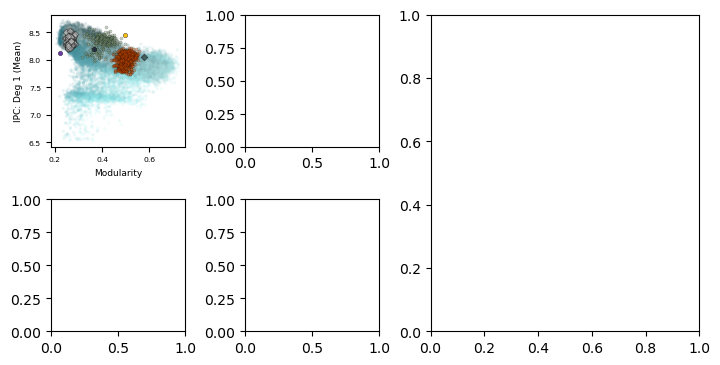

In [3]:
# ax = axes[panel_id]
fig, axes = plt.subplot_mosaic(
    """
    ABEE
    CDEE
    """,
    figsize=viz.cm_to_inch((18, 9)),
    layout="constrained",
)
ax = axes["A"]
# x_col = "ipc_ipc_deg1_mean"
x_col = "modularity"
y_col = "ipc_ipc_deg1_mean"
# y_col = "mc_input_scaling_0_1_mc_mean"
for dataset in datasets_to_plot:
    if (not INCLUDE_LEXIS) and ("lexi" in dataset):
        continue

    df_merged = dict_with_all_datasets[dataset]
    # x_col, y_col = pcfg["x"], pcfg["y"]
    if x_col not in df_merged.columns or y_col not in df_merged.columns:
        continue

    is_gnm = dataset == "hcp_schaefer_100_dataset_gnm"
    is_kaysons = "kaysons" in dataset
    is_reference = dataset in ("ring_lattice_networks", "erdos_renyi_networks")

    ax.scatter(
        df_merged[x_col],
        df_merged[y_col],
        color=combined_colors if is_gnm else COLOR_SCHEME[dataset],
        edgecolor="black" if not is_gnm else "none",
        linewidth=0.4 if is_reference else 0.25 if not is_gnm else 0,
        s=12 if is_reference else 10 if is_kaysons else 5,
        marker="D" if is_reference else "o",
        alpha=0.15 if is_gnm else 0.6 if is_reference else 1.0 if is_kaysons else 0.4,
        # label=LABEL_MAP[dataset] if panel_id == "A" else None,
        zorder=5 if is_reference else 4 if is_kaysons else 1 if is_gnm else 2,
        rasterized=is_gnm,
    )

ax.set_xlabel(PROPERTY_NAMES.get(x_col, x_col), fontsize=6.5)
ax.set_ylabel(PROPERTY_NAMES.get(y_col, y_col), fontsize=6.5)
ax.tick_params(labelsize=5.5)
# ax.set_title(f"{panel_id}  {pcfg['title']}", fontsize=7, loc="left")
